# Fake News Detection with NLP

**Objective:** Classify news-like text while documenting uncertainty, source verification, and the limits of linguistic signals.

This notebook uses deterministic demo text so the complete workflow runs without private or externally hosted data. Labels are used only for supervised training and evaluation.


## 1. Setup and reproducibility


In [1]:
import platform
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
sns.set_theme(style="whitegrid", palette="deep")

print(f"Python: {platform.python_version()}")
print(f"pandas: {pd.__version__} | NumPy: {np.__version__} | scikit-learn: {sklearn.__version__}")
print(f"Random seed: {RANDOM_STATE}")


Python: 3.12.13
pandas: 2.2.3 | NumPy: 2.3.5 | scikit-learn: 1.8.0
Random seed: 42


## 2. Build the documented demo dataset


In [2]:
TOPICS = {
  "credible": [
    "report",
    "evidence",
    "official",
    "research",
    "statement",
    "verified",
    "source",
    "data"
  ],
  "misleading": [
    "shocking",
    "secret",
    "miracle",
    "exposed",
    "urgent",
    "unbelievable",
    "viral",
    "hidden"
  ]
}
COMMON_WORDS = ["customer", "service", "today", "online", "request", "information", "please", "system"]
rows = []
for label, vocabulary in TOPICS.items():
    for row_id in range(180):
        signal = rng.choice(vocabulary, size=6, replace=True).tolist()
        context = rng.choice(COMMON_WORDS, size=4, replace=True).tolist()
        other_labels = [name for name in TOPICS if name != label]
        cross_noise = []
        if rng.random() < 0.35:
            other = rng.choice(other_labels)
            cross_noise = rng.choice(TOPICS[other], size=3, replace=True).tolist()
        tokens = signal + context + cross_noise
        rng.shuffle(tokens)
        observed_label = rng.choice(other_labels) if rng.random() < 0.08 else label
        rows.append({"article_text": " ".join(tokens), "news_label": observed_label})

data = pd.DataFrame(rows).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
print(f"Dataset shape: {data.shape[0]:,} rows × {data.shape[1]} columns")
display(data.head())
display(data["news_label"].value_counts().rename("count").to_frame())


Dataset shape: 360 rows × 2 columns


,article_text,news_label
0,unbelievable statement unbelievable urgent req...,misleading
1,verified request request official evidence res...,credible
2,customer information shocking shocking viral c...,misleading
3,exposed urgent today unbelievable exposed expo...,credible
4,evidence data research please system statement...,credible


,count
news_label,
credible,182
misleading,178


## 3. Data quality and exploratory analysis


,dtype,missing,unique
article_text,object,0,360
news_label,object,0,2


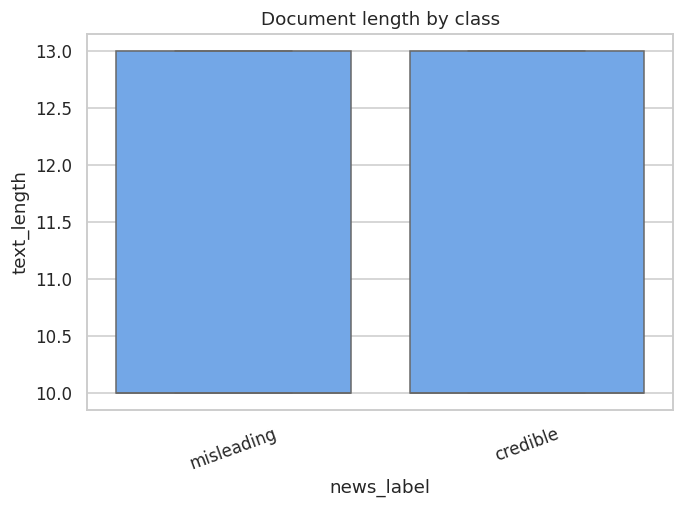

In [3]:
quality = pd.DataFrame({
    "dtype": data.dtypes.astype(str),
    "missing": data.isna().sum(),
    "unique": data.nunique(),
})
display(quality)
data["text_length"] = data["article_text"].str.split().str.len()
sns.boxplot(data=data, x="news_label", y="text_length", color="#60a5fa")
plt.title("Document length by class")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


## 4. Leakage-safe split, baseline, and candidate models


In [4]:
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report, f1_score
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline

X_train, X_test, y_train, y_test = train_test_split(
    data["article_text"], data["news_label"], test_size=0.25,
    random_state=RANDOM_STATE, stratify=data["news_label"],
)
models = {
    "Majority baseline": Pipeline([("tfidf", TfidfVectorizer()), ("model", DummyClassifier(strategy="prior"))]),
    "Multinomial Naive Bayes": Pipeline([("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=2)), ("model", MultinomialNB(alpha=0.6))]),
    "Logistic Regression": Pipeline([("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True)), ("model", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))]),
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
comparison = []
for name, model in models.items():
    scores = cross_validate(model, X_train, y_train, cv=cv, scoring="f1_macro", n_jobs=1)
    comparison.append({"model": name, "cv_macro_f1": scores["test_score"].mean(), "cv_std": scores["test_score"].std()})
comparison = pd.DataFrame(comparison).sort_values("cv_macro_f1", ascending=False).reset_index(drop=True)
display(comparison.round(4))


,model,cv_macro_f1,cv_std
0,Multinomial Naive Bayes,0.9296,0.0246
1,Logistic Regression,0.9296,0.0246
2,Majority baseline,0.3350,0.0033


## 5. Holdout evaluation


Selected model: Multinomial Naive Bayes
Holdout accuracy: 0.8444
Holdout macro F1: 0.8444


,precision,recall,f1-score,support
credible,0.8810,0.8043,0.8409,46.0000
misleading,0.8125,0.8864,0.8478,44.0000
accuracy,0.8444,0.8444,0.8444,0.8444
macro avg,0.8467,0.8454,0.8444,90.0000
weighted avg,0.8475,0.8444,0.8443,90.0000


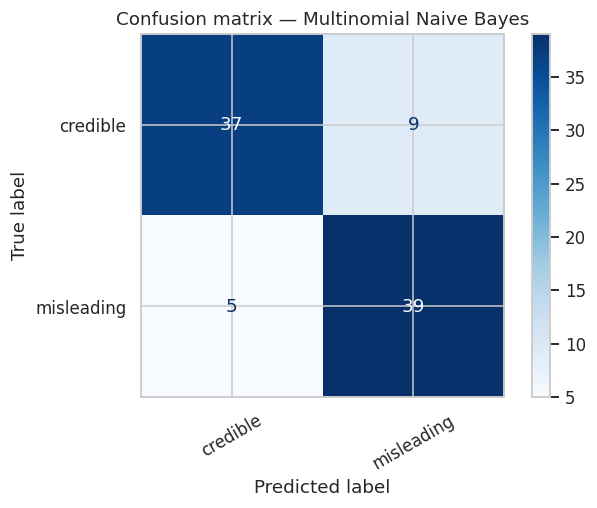

In [5]:
best_name = comparison.iloc[0]["model"]
best_model = models[best_name].fit(X_train, y_train)
predictions = best_model.predict(X_test)
print(f"Selected model: {best_name}")
print(f"Holdout accuracy: {accuracy_score(y_test, predictions):.4f}")
print(f"Holdout macro F1: {f1_score(y_test, predictions, average='macro'):.4f}")
display(pd.DataFrame(classification_report(y_test, predictions, output_dict=True, zero_division=0)).T.round(4))
ConfusionMatrixDisplay.from_predictions(y_test, predictions, cmap="Blues", xticks_rotation=30)
plt.title(f"Confusion matrix — {best_name}")
plt.tight_layout()
plt.show()


## 6. Model interpretation and sample predictions


In [6]:
if best_name == "Logistic Regression":
    vectorizer = best_model.named_steps["tfidf"]
    classifier = best_model.named_steps["model"]
    terms = np.asarray(vectorizer.get_feature_names_out())
    rows = []
    coefficients = classifier.coef_ if len(classifier.classes_) > 2 else np.vstack([-classifier.coef_[0], classifier.coef_[0]])
    for class_name, weights in zip(classifier.classes_, coefficients):
        for term, weight in zip(terms[np.argsort(weights)[-8:]], np.sort(weights)[-8:]):
            rows.append({"class": class_name, "term": term, "weight": weight})
    display(pd.DataFrame(rows).sort_values(["class", "weight"], ascending=[True, False]).round(3))

sample = pd.DataFrame({"text": X_test.iloc[:8], "actual": y_test.iloc[:8], "predicted": predictions[:8]})
display(sample)


,text,actual,predicted
36,official unbelievable viral online service off...,credible,credible
26,verified data request please data report resea...,credible,credible
187,service customer shocking miracle unbelievable...,misleading,misleading
236,source system data report research system toda...,credible,credible
196,verified evidence research shocking source dat...,misleading,credible
195,report information information statement syste...,credible,credible
255,evidence online please secret research system ...,misleading,misleading
231,secret viral unbelievable miracle request toda...,misleading,misleading


## 7. Responsible-use notes and next steps

- Replace deterministic demo text with versioned, licensed, representative data.
- Review class definitions, annotation quality, subgroup performance, and threshold costs with domain experts.
- Keep humans in the loop for hiring, moderation, security, healthcare, finance, and other consequential decisions.
- Monitor vocabulary drift and abstain when confidence or data quality is low.
